In [ ]:
# Regression on Salaries data
# Basic file
# G.Vinueza 20250902
# ===============================
# Step 1: Import libraries
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score




In [3]:
# ===============================
# Step 2: Load the dataset
# ===============================
df = pd.read_csv("Dataset_Salaries.csv")
df.head()

,Anos_Exp,Salario
0,1.2,"$39,344"
1,1.4,"$46,206"
2,1.6,"$37,732"
3,2.1,"$43,526"
4,2.3,"$39,892"


In [4]:
# ===============================
# Step 3: Data Cleaning
# ===============================
# The "Salario" column has $ signs and commas. Let's clean it.
df["Salario"] = (
    df["Salario"]
    .replace({'\$':'', ',':''}, regex=True)  # remove $ and commas
    .astype(float)                           # convert to numeric
)



<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-762245679.py:7: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$':'', ',':''}, regex=True)  # remove $ and commas


In [6]:
df.head()

,Anos_Exp,Salario
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


Head
   Anos_Exp  Salario
0       1.2  39344.0
1       1.4  46206.0
2       1.6  37732.0
3       2.1  43526.0
4       2.3  39892.0

Basic Statistics
        Anos_Exp        Salario
count  30.000000      30.000000
mean    5.413333   76004.000000
std     2.837888   27414.429785
min     1.200000   37732.000000
25%     3.300000   56721.750000
50%     4.800000   65238.000000
75%     7.800000  100545.750000
max    10.600000  122392.000000

Check Missing Values
Anos_Exp    0
Salario     0
dtype: int64

Scatterplot


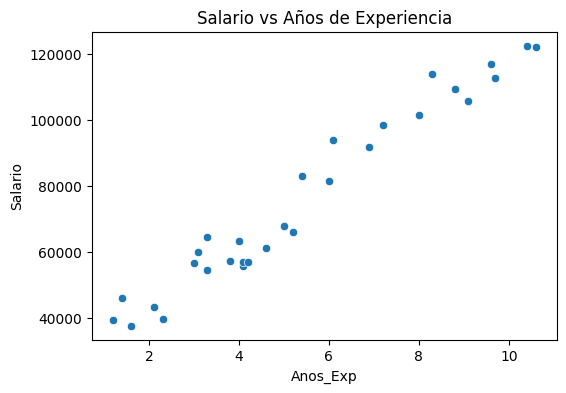


Correlation


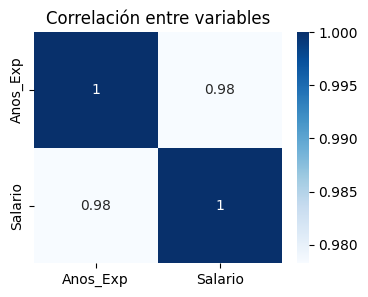

In [9]:
# ===============================
# Step 4: Exploratory Data Analysis (EDA)
# ===============================

# 4.1: Look at the first rows
print("Head")
print(df.head())
print ("")

# 4.2: Basic statistics
print("Basic Statistics")
print(df.describe())
print ("")

# 4.3: Check for missing values
print("Check Missing Values")
print(df.isnull().sum())
print ("")

# 4.4: Simple scatterplot of Experience vs Salary
print("Scatterplot")
plt.figure(figsize=(6,4))
sns.scatterplot(x="Anos_Exp", y="Salario", data=df)
plt.title("Salario vs Años de Experiencia")
plt.show()
print ("")

# 4.5: Correlation heatmap
print("Correlation")
plt.figure(figsize=(4,3))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlación entre variables")
plt.show()
print ("")


In [10]:
# ===============================
# Step 5: Regression Model
# ===============================

# 5.1: Define features (X) and target (y)
X = df[["Anos_Exp"]]   # Independent variable
y = df["Salario"]      # Dependent variable

# 5.2: Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5.3: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 5.4: Make predictions
y_pred = model.predict(X_test)

# 5.5: Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))



Mean Squared Error: 49830096.855908334
R2 Score: 0.9024461774180498


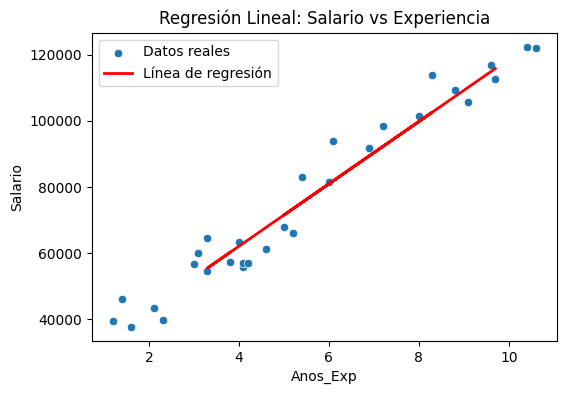

In [11]:
# ===============================
# Step 6: Visualize regression line
# ===============================
plt.figure(figsize=(6,4))
sns.scatterplot(x="Anos_Exp", y="Salario", data=df, label="Datos reales")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Línea de regresión")
plt.title("Regresión Lineal: Salario vs Experiencia")
plt.legend()
plt.show()

In [12]:
# ===============================
# Step 7: Regression with Statsmodels (to get P-values and F-statistic)
# ===============================
import statsmodels.api as sm

# Add a constant (intercept term) to the model
X_sm = sm.add_constant(X)

# Fit the OLS (Ordinary Least Squares) regression
model_sm = sm.OLS(y, X_sm).fit()

# Print the full summary (includes coefficients, p-values, R2, F-statistic, etc.)
print(model_sm.summary())

# ===============================
# Notes for Students:
# ===============================
# - The "coef" column shows the intercept and slope of the regression line.
# - The "P>|t|" column shows the p-value for each coefficient.
#   If it is less than 0.05, we usually say the coefficient is statistically significant.
# - The "F-statistic" at the top tests if the overall regression model is significant.
# - "R-squared" tells us how much of the salary variation is explained by experience.


                            OLS Regression Results                            
Dep. Variable:                Salario   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Tue, 02 Sep 2025   Prob (F-statistic):           1.14e-20
Time:                        00:59:05   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.485e+04   2306.654     10.772      0.0